In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd

In [3]:
path = "/content/drive/MyDrive/Jobaaj Dataset/Statistics.xlsx"
data = pd.read_excel(path)

In [4]:
data.head()

,application_id,Interview Taken on,Status,event_name,Department,Post Name,Offered Salary
0,383422,2014-05-01 11:40:00,Hired,Male,Service Department,c8,56553.0
1,907518,2014-05-06 08:08:00,Hired,Female,Service Department,c5,22075.0
2,176719,2014-05-06 08:08:00,Rejected,Male,Service Department,c5,70069.0
3,429799,2014-05-02 16:28:00,Rejected,Female,Operations Department,i4,3207.0
4,253651,2014-05-02 16:32:00,Hired,Male,Operations Department,i4,29668.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7168 entries, 0 to 7167
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   application_id      7168 non-null   int64         
 1   Interview Taken on  7168 non-null   datetime64[ns]
 2   Status              7168 non-null   object        
 3   event_name          7168 non-null   object        
 4   Department          7168 non-null   object        
 5   Post Name           7168 non-null   object        
 6   Offered Salary      7167 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 392.1+ KB


In [6]:
data.shape

(7168, 7)

In [7]:
data.isnull().sum()

,0
application_id,0
Interview Taken on,0
Status,0
event_name,0
Department,0
Post Name,0
Offered Salary,1


In [8]:
data.describe()

,application_id,Interview Taken on,Offered Salary
count,7168.000000,7168,7167.000000
mean,508648.534459,2014-07-02 20:11:00.058593792,49983.029022
min,12073.000000,2014-05-01 03:38:00,100.000000
25%,262283.500000,2014-06-02 11:09:45,25460.500000
50%,508025.000000,2014-07-04 00:02:30,49625.000000
75%,757345.250000,2014-08-01 13:12:15,74438.000000
max,999936.000000,2014-08-31 20:58:00,400000.000000
std,285146.164429,NaN,28854.176890


In [9]:
data.duplicated().sum()

np.int64(0)

Dropping the null data

In [10]:
data['Offered Salary'].isnull().sum()

np.int64(1)

In [11]:
data = data.dropna(subset=['Offered Salary'])

In [12]:
data['Offered Salary'].isnull().sum()

np.int64(0)

Dropping the invalid data

In [13]:
data = data[data['event_name'] != "-" ]


In [14]:
data.shape

(7152, 7)

Hirirg Analysis

In [15]:
Hired = data[data['Status'] == 'Hired'].groupby('event_name').agg({'application_id': 'count'}).sort_values(by='application_id', ascending=False)
Hired

,application_id
event_name,
Male,2563
Female,1856
Don’t want to say,268


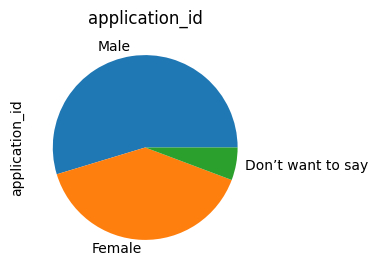

In [16]:
from matplotlib import pyplot as plt
Hired['application_id'].plot(kind='pie', figsize=(6, 3), title='application_id')
plt.gca().spines[['top', 'right']].set_visible(False)

Salary Analysis

In [17]:
Salary_event_name = data[data['Status'] == 'Hired'].groupby('event_name').agg({'Offered Salary': 'sum'}).sort_values(by='Offered Salary', ascending=False)
Salary_event_name

,Offered Salary
event_name,
Male,127968267.0
Female,91630300.0
Don’t want to say,13547492.0


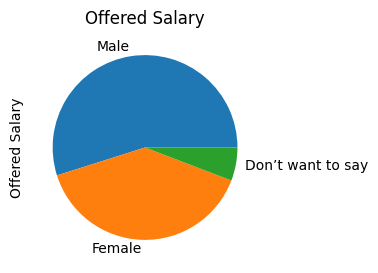

In [18]:
# Offered Salary
Salary_event_name['Offered Salary'].plot(kind='pie', figsize=(6, 3), title='Offered Salary')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [19]:
Average_event_name = data[data['Status'] == 'Hired'].groupby('event_name').agg({'Offered Salary': 'mean'}).sort_values(by='Offered Salary', ascending=True)
Average_event_name

,Offered Salary
event_name,
Female,49369.773707
Male,49929.093640
Don’t want to say,50550.343284


In [20]:
Salary_department = data[data['Status'] == 'Hired'].groupby('Department').agg({'Offered Salary': 'sum'}).sort_values(by='Offered Salary', ascending=False)
Salary_department

,Offered Salary
Department,
Operations Department,89948471.0
Service Department,67163348.0
Sales Department,23461420.0
Production Department,12140315.0
Purchase Department,11979912.0
Marketing Department,9570334.0
Finance Department,8579698.0
General Management,6871553.0
Human Resource Department,3431008.0


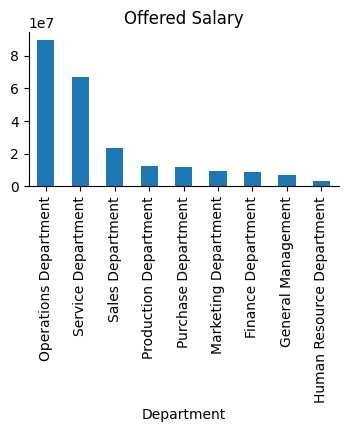

In [21]:
Salary_department['Offered Salary'].plot(kind='bar', figsize=(4, 2), title='Offered Salary')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [22]:
Average_department = data[data['Status'] == 'Hired'].groupby('Department').agg({'Offered Salary': 'mean'}).sort_values(by='Offered Salary', ascending=True)
Average_department

,Offered Salary
Department,
Marketing Department,47613.601990
Sales Department,48474.008264
Finance Department,48748.284091
Operations Department,48885.038587
Human Resource Department,49014.400000
Production Department,49350.873984
Service Department,50612.922381
Purchase Department,52086.573913
General Management,60810.203540


Salary distribution

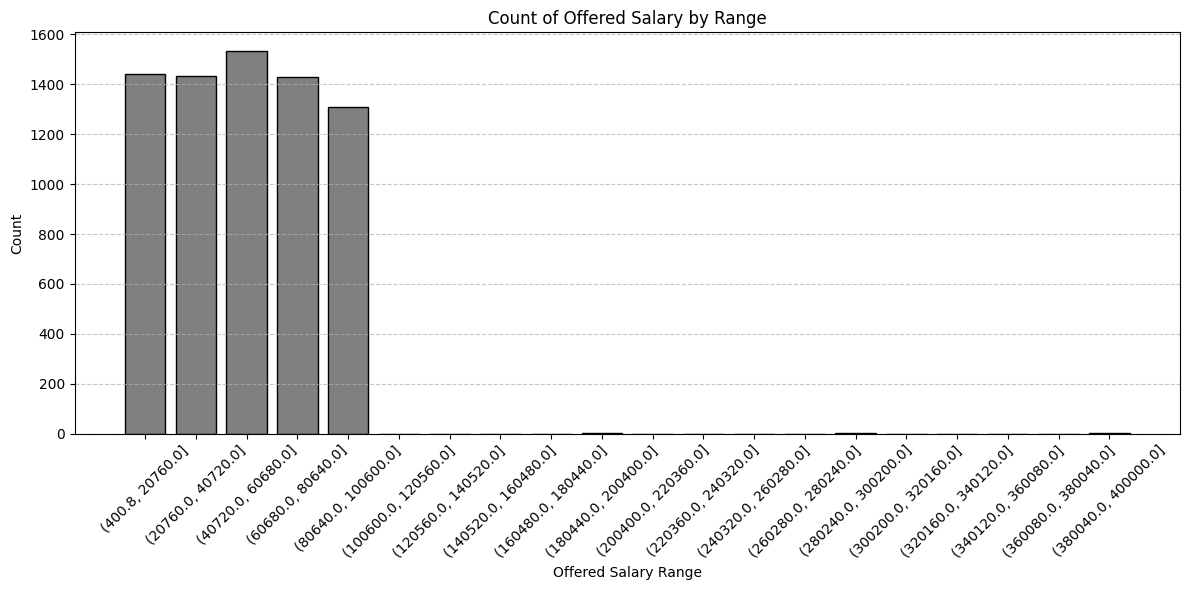

In [23]:
plt.figure(figsize=(12, 6))
salary_bins = pd.cut(data['Offered Salary'], bins=20)
salary_counts = salary_bins.value_counts().sort_index()

plt.bar(salary_counts.index.astype(str), salary_counts.values, color='grey', edgecolor='black')

plt.title("Count of Offered Salary by Range")
plt.xlabel("Offered Salary Range")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Departmental Analysis

In [24]:
department_analysis = data.groupby('Department')['Status'].value_counts().unstack()
department_analysis

Status,Hired,Rejected
Department,,
Finance Department,176,112
General Management,113,59
Human Resource Department,70,27
Marketing Department,201,123
Operations Department,1840,927
Production Department,246,133
Purchase Department,230,102
Sales Department,484,261
Service Department,1327,721


In [25]:
Hired = data[data['Status'] == 'Hired'].groupby('Department').agg({'Offered Salary': 'sum'}).sort_values(by='Offered Salary', ascending=False)
Hired


,Offered Salary
Department,
Operations Department,89948471.0
Service Department,67163348.0
Sales Department,23461420.0
Production Department,12140315.0
Purchase Department,11979912.0
Marketing Department,9570334.0
Finance Department,8579698.0
General Management,6871553.0
Human Resource Department,3431008.0


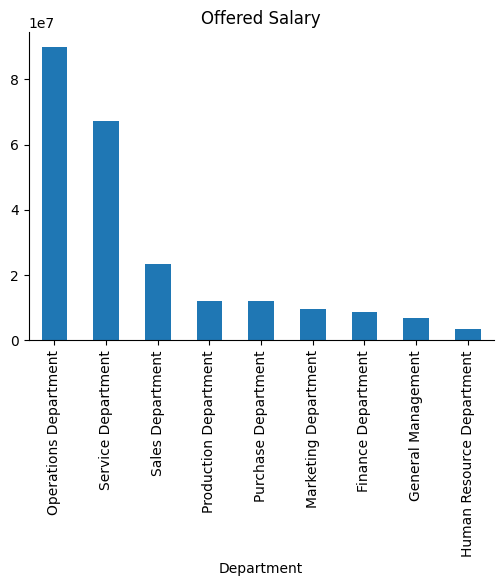

In [26]:
Hired['Offered Salary'].plot(kind='bar', figsize=(6, 4), title='Offered Salary')
plt.gca().spines[['top', 'right',]].set_visible(False)

## Conclusion Analysis

Based on the analysis performed:

* **Hiring by Gender:** More males were hired than females, with a significant number also choosing not to disclose their gender.
* **Total Offered Salary by Gender:** The total offered salary aligns with the number of hires, showing a higher total for males, followed by females and those who preferred not to say.
* **Average Offered Salary by Gender:** The average offered salary is remarkably similar across all gender categories. This suggests that while more individuals of one gender might be hired or receive a higher total salary, the average compensation per person is quite equitable.
* **Total Offered Salary by Department:** The Operations Department has the highest total offered salary, followed by Service and Sales Departments. This is likely due to a combination of the number of hires and potentially higher salaries in those departments.
* **Average Offered Salary by Department:** The average offered salary varies more significantly across departments compared to gender. General Management, Purchase, and Service Departments show higher average salaries, while Marketing, Sales, and Finance Departments have lower averages.
* **Salary Distribution:** The distribution of offered salaries shows a concentration in the lower ranges, with a rapid decrease in the number of hires as the salary increases. This indicates that most positions filled are in the lower to mid-salary brackets.
* **Departmental Analysis (Hired vs. Rejected):** The Operations and Service Departments have the highest number of hires and rejections, likely reflecting a higher volume of applications in these areas. The ratio of hired to rejected applicants varies by department, which could be an area for further investigation into recruitment processes and requirements.

Overall, the analysis reveals insights into hiring patterns, salary distribution, and departmental performance based on the provided data. Further investigation into the reasons behind the varying average salaries across departments and the hire/rejection ratios could provide valuable insights for improving recruitment and compensation strategies.